<a href="https://colab.research.google.com/github/emersonnjsantos/visao_computacional_mini_dataset/blob/main/notebooks/relatorio_atividade_1_projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Relatório Técnico: Fundamentos de Processamento Digital de Imagens (PDI)
**Programa:** Residência em TIC43 — Módulo de Visão Computacional (Softex / MCTI)
**Aluno:** Emerson Noe Jose dos Santos
**Docentes:** Prof. Alyson Bezerra | Prof. Matheus Araújo
**Repositório do Projeto:** [github.com/emersonnjsantos/visao_computacional_mini_dataset](https://github.com/emersonnjsantos/visao_computacional_mini_dataset)
---

##  1. Visão Geral do Projeto e Objetivos
Este projeto prático simula as etapas fundamentais de um pipeline profissional de Visão Computacional, abordando desde a **aquisição controlada de imagens** no mundo real até a **análise técnica de transformações digitais**.

O objetivo central é construir um mini dataset balanceado (2 classes, 10 imagens próprias) e investigar experimentalmente como escolhas de engenharia — resolução, representação cromática, quantização e formatos de compressão — impactam a fidelidade visual, a integridade dos dados e a viabilidade computacional antes do treinamento de modelos de Machine Learning/Deep Learning.

---

##  2. Ferramentas e Ambiente de Desenvolvimento
* **Linguagem:** Python 3.10+
* **Bibliotecas Principais:**
  * `OpenCV (cv2)`: Leitura, conversão de espaços de cor, redimensionamento, cálculo de histogramas e quantização.
  * `NumPy`: Manipulações matriciais e operações vetorizadas sobre os pixels.
  * `Matplotlib`: Renderização gráfica lado a lado e plotagem de curvas de distribuição estatística.
* **Ambiente de Execução:** Google Colab (ambiente na nuvem com runtime Linux).
* **Controle de Versão e Armazenamento:** Git e GitHub (repositório estruturado com padrão de Machine Learning).
* **Dispositivo de Captura:** Smartphone Xiaomi 11 Pro (sensor principal de 108 MP, lente grande-angular com abertura f/1.9).

---

##  3. Metadados do Dataset e Estratégia de Aquisição
* **Classe A (Flores):** 5 amostras originais (`dataset/classe_A/img001_original.jpg` a `img005_original.jpg`).
* **Classe B (Folhas):** 5 amostras originais (`dataset/classe_B/img006_original.jpg` a `img010_original.jpg`).
* **Condições de Iluminação:**
  1. *Luz Natural Direta:* Amostras capturadas sob sol pleno para avaliar contraste intenso e presença de sombras duras.
  2. *Luz Natural Difusa (Sombra):* Capturas em ambiente sombreado para analisar distribuição suave de luminância.
  3. *Luz Artificial (LED):* Capturas internas com temperatura de cor artificial.
* **Distâncias e Ângulos:** Variação sistemática entre tomadas macro/close-up (15 cm a 25 cm) e planos médios (60 cm a 1 m), com perspectivas zenital (topo) e angulada (45°).

---

##  4. Desafios Encontrados e Soluções Aplicadas
1. **Controle Óptico e Resolução Extrema (108 MP):**
   * *Dificuldade:* O sensor grande produziu profundidade de campo muito rasa (*bokeh* natural) em tomadas aproximadas e gerou arquivos excessivamente pesados para processamento direto.
   * *Solução:* Desativação completa de filtros automáticos de embelezamento/IA da câmera e aplicação de técnicas de interpolação por área (`cv2.INTER_AREA`) para reduções de resolução sem perda de consistência estrutural.
2. **Distribuição Cromática e Iluminação:**
   * *Dificuldade:* Variações de sombra alteravam fortemente os valores brutos no espaço RGB.
   * *Solução:* Adoção do espaço HSV para desacoplar a informação de matiz puro ($H$) da intensidade de luz ($V$), viabilizando segmentação robusta.
3. **Organização e Pipeline de Código:**
   * *Dificuldade:* Padronização rigorosa da estrutura de diretórios e tratamento de indexação dimensional ao plotar matrizes complexas no `Matplotlib`.
   * *Solução:* Construção de um pipeline modular que carrega os dados automaticamente do GitHub e processa cada método no padrão didático estabelecido pela mentoria.

---

##  5. Estrutura Didática das Células do Notebook
Para garantir reprodutibilidade e clareza analítica, todas as etapas práticas a seguir foram organizadas no padrão:
$$\textbf{Problema / Contexto} \longrightarrow \textbf{Código de Execução} \longrightarrow \textbf{Visualização Gráfica} \longrightarrow \textbf{Interpretação Técnica}$$

* **Célula 1 — Setup & Dataset:** Inicialização do repositório, carregamento e exibição das 10 imagens originais.
* **Célula 2 — Histogramas:** Análise comparativa da faixa dinâmica em escala de cinza e das curvas de cor RGB para todas as amostras.
* **Célula 3 — Resolução Espacial:** Estudo do impacto da subamostragem (Original vs 50% vs 20%) nas altas frequências e texturas.
* **Célula 4 — Espaços de Cor:** Avaliação funcional de RGB, HSV e Escala de Cinza em tarefas de segmentação e extração de características.
* **Célula 5 — Quantização:** Efeitos de degradação tonal, falso contorno (*color banding*) e binarização (256, 64, 32 e 2 níveis).
* **Célula 6 — Formatos de Arquivo:** Comparação quantitativa de taxa de compressão e artefatos de bloco (JPEG com perdas vs PNG sem perdas).
* **Célula 7 — Tabela Resumo e Conclusões:** Síntese de engenharia e respostas às questões norteadoras da atividade.

Cloning into 'visao_computacional_mini_dataset'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 56 (delta 23), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 9.74 MiB | 7.90 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/visao_computacional_mini_dataset



#  Relatório de Visão Computacional — Atividade 1: Fundamentos de PDI
---
###  PROBLEMA 1: Aquisição e Estruturação do Dataset
* **Objetivo:** Construir um mini dataset balanceado (2 classes, 10 imagens) com controle de iluminação e distância para análise de PDI.
* **Metadados de Aquisição:**
  * **Dispositivo:** Xiaomi 11 Pro (sensor principal de 108 MP, f/1.9).
  * **Classes:** Classe A (Flores, img001 a img005) | Classe B (Folhas, img006 a img010).
  * **Iluminação:** Variação controlada entre sol pleno (luz direta dura), sombra (luz difusa) e ambiente interno (LED artificial).
  * **Distância e Ângulos:** Macro (15–25 cm) e plano médio (60 cm–1 m); ângulos a 45° e zenital.
---


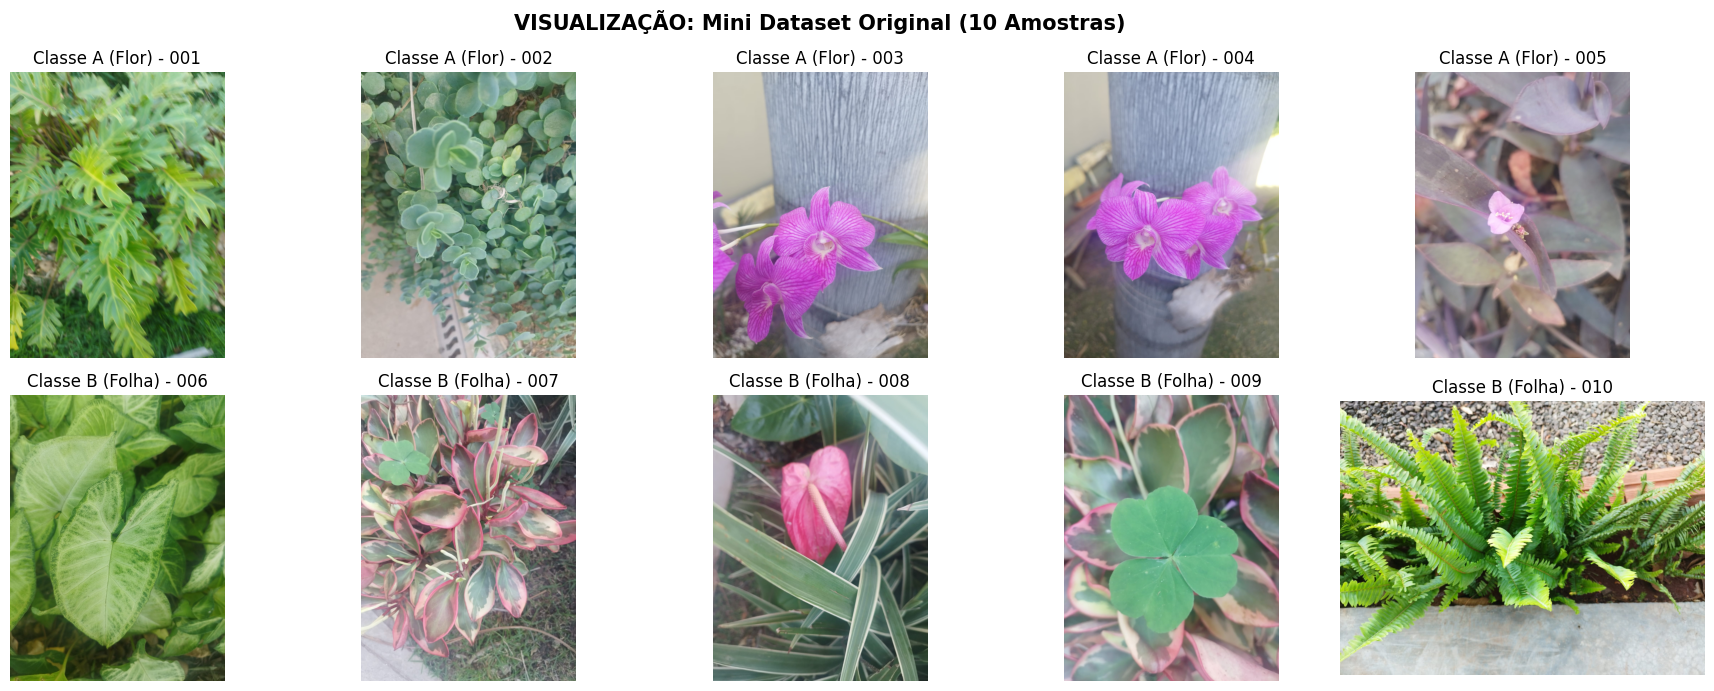


* **INTERPRETAÇÃO:** O dataset apresenta boa variabilidade intra-classe (diferentes espécies e iluminações) e forte distinção inter-classe. O sensor de 108 MP proporciona alta densidade de informação espacial original, com profundidade de campo rasa em capturas macro.


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# 1. Clonar repositório
if not os.path.exists("visao_computacional_mini_dataset"):
    !git clone https://github.com/emersonnjsantos/visao_computacional_mini_dataset.git
%cd visao_computacional_mini_dataset

# Criar pastas de outputs
os.makedirs("outputs/resolucao", exist_ok=True)
os.makedirs("outputs/espaco_cor", exist_ok=True)
os.makedirs("outputs/quantizacao", exist_ok=True)
os.makedirs("outputs/formatos", exist_ok=True)

# 2. Exibição do Problema e Metadados
display(Markdown("""
#  Relatório de Visão Computacional — Atividade 1: Fundamentos de PDI
---
###  PROBLEMA 1: Aquisição e Estruturação do Dataset
* **Objetivo:** Construir um mini dataset balanceado (2 classes, 10 imagens) com controle de iluminação e distância para análise de PDI.
* **Metadados de Aquisição:**
  * **Dispositivo:** Xiaomi 11 Pro (sensor principal de 108 MP, f/1.9).
  * **Classes:** Classe A (Flores, img001 a img005) | Classe B (Folhas, img006 a img010).
  * **Iluminação:** Variação controlada entre sol pleno (luz direta dura), sombra (luz difusa) e ambiente interno (LED artificial).
  * **Distância e Ângulos:** Macro (15–25 cm) e plano médio (60 cm–1 m); ângulos a 45° e zenital.
---
"""))

# 3. Código de Visualização do Dataset
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(1, 6):
    img = cv2.imread(f"dataset/classe_A/img{i:03d}_original.jpg")
    if img is not None:
        axes[0, i-1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, i-1].set_title(f"Classe A (Flor) - {i:03d}")
    axes[0, i-1].axis('off')

for i in range(6, 11):
    img = cv2.imread(f"dataset/classe_B/img{i:03d}_original.jpg")
    if img is not None:
        # CORREÇÃO: Acessar a segunda linha [1] e ajustar o índice da coluna
        axes[1, i-6].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[1, i-6].set_title(f"Classe B (Folha) - {i:03d}")
    axes[1, i-6].axis('off')

plt.suptitle("VISUALIZAÇÃO: Mini Dataset Original (10 Amostras)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Interpretação
display(Markdown("""
* **INTERPRETAÇÃO:** O dataset apresenta boa variabilidade intra-classe (diferentes espécies e iluminações) e forte distinção inter-classe. O sensor de 108 MP proporciona alta densidade de informação espacial original, com profundidade de campo rasa em capturas macro.
"""))


---
###  PROBLEMA 2: Impacto da Redução de Resolução Espacial
* **Objetivo:** Avaliar a perda de detalhes finos (altas frequências) ao subamostrar a imagem original em 50% e 20%, ponderando o custo computacional em modelos de Visão Computacional.


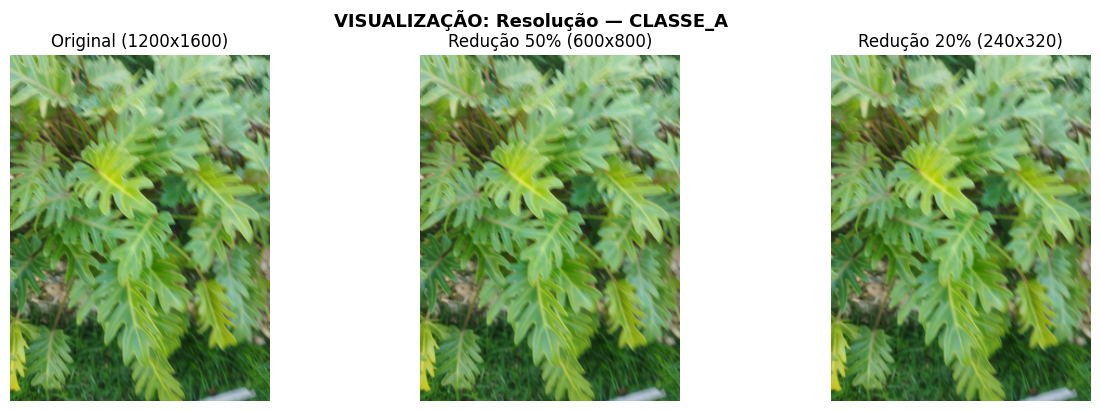

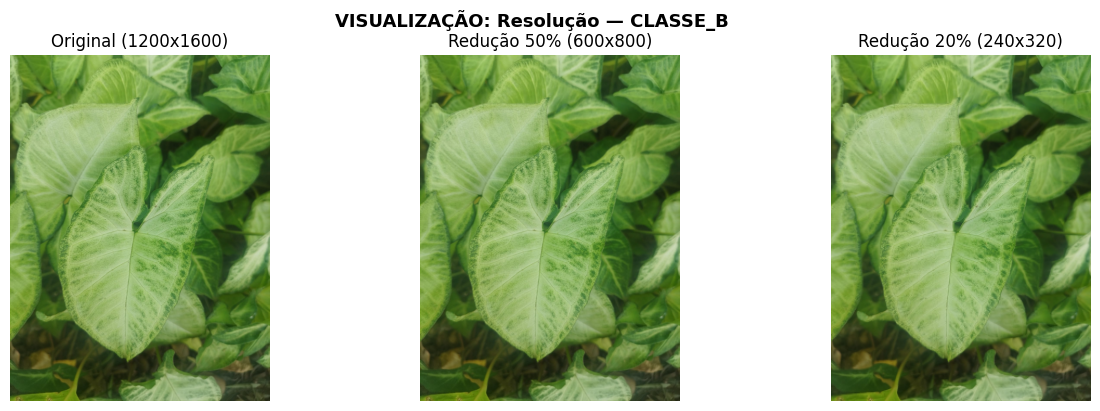


* **INTERPRETAÇÃO:**
  * *Perda perceptível:* A redução de 50% preserva as bordas e características primárias. A redução de 20% elimina texturas sutis (como nervuras secundárias e grãos das pétalas), gerando aliasing.
  * *Impacto em VC:* Imagens em resolução nativa (108 MP) são inviáveis para treino de CNNs/Transformers devido ao consumo proibitivo de VRAM. A redução de escala é fundamental para viabilizar o processamento em tempo real sem prejudicar a classificação macroscópica.


In [3]:
img_a = cv2.imread("dataset/classe_A/img001_original.jpg")
img_b = cv2.imread("dataset/classe_B/img006_original.jpg")

display(Markdown("""
---
###  PROBLEMA 2: Impacto da Redução de Resolução Espacial
* **Objetivo:** Avaliar a perda de detalhes finos (altas frequências) ao subamostrar a imagem original em 50% e 20%, ponderando o custo computacional em modelos de Visão Computacional.
"""))

def executar_resolucao(img, nome_classe):
    h, w = img.shape[:2]
    img_50 = cv2.resize(img, (int(w * 0.5), int(h * 0.5)), interpolation=cv2.INTER_AREA)
    img_20 = cv2.resize(img, (int(w * 0.2), int(h * 0.2)), interpolation=cv2.INTER_AREA)

    cv2.imwrite(f"outputs/resolucao/{nome_classe}_original.jpg", img)
    cv2.imwrite(f"outputs/resolucao/{nome_classe}_50pct.jpg", img_50)
    cv2.imwrite(f"outputs/resolucao/{nome_classe}_20pct.jpg", img_20)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original ({w}x{h})")
    axes[0].axis('off')

    # Correção: Acessar o subplot correto usando índices
    axes[1].imshow(cv2.cvtColor(img_50, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Redução 50% ({img_50.shape[1]}x{img_50.shape[0]})")
    axes[1].axis('off')

    # Correção: Acessar o subplot correto usando índices
    axes[2].imshow(cv2.cvtColor(img_20, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Redução 20% ({img_20.shape[1]}x{img_20.shape[0]})")
    axes[2].axis('off')

    plt.suptitle(f"VISUALIZAÇÃO: Resolução — {nome_classe.upper()}", fontsize=13, fontweight='bold')
    plt.show()

executar_resolucao(img_a, "classe_A")
executar_resolucao(img_b, "classe_B")

display(Markdown("""
* **INTERPRETAÇÃO:**
  * *Perda perceptível:* A redução de 50% preserva as bordas e características primárias. A redução de 20% elimina texturas sutis (como nervuras secundárias e grãos das pétalas), gerando aliasing.
  * *Impacto em VC:* Imagens em resolução nativa (108 MP) são inviáveis para treino de CNNs/Transformers devido ao consumo proibitivo de VRAM. A redução de escala é fundamental para viabilizar o processamento em tempo real sem prejudicar a classificação macroscópica.
"""))


---
###  PROBLEMA 3: Representação Cromática e Espaços de Cor
* **Objetivo:** Comparar os espaços de cor RGB, HSV e Escala de Cinza, avaliando o desacoplamento de iluminação e a utilidade para tarefas específicas de Visão Computacional.


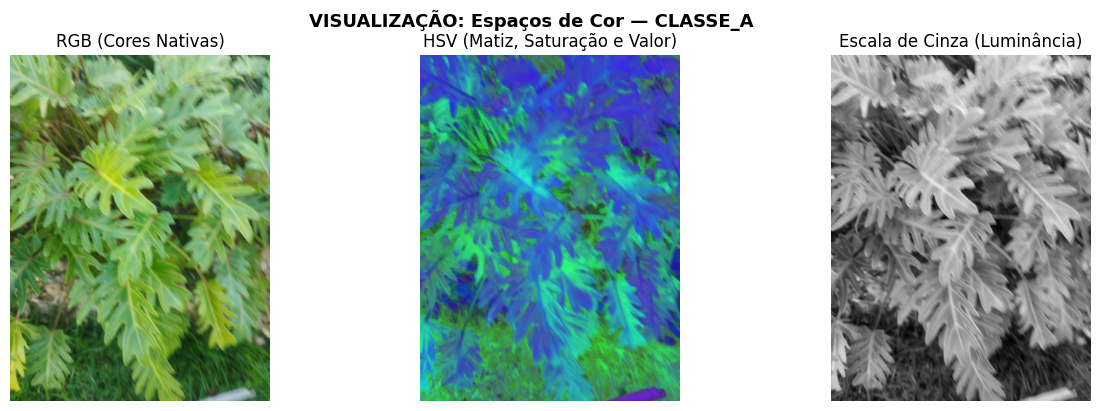

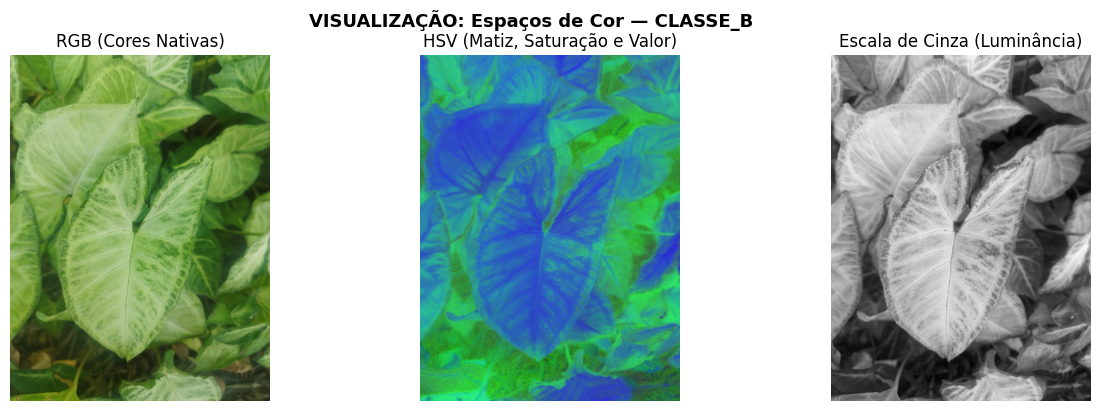


* **INTERPRETAÇÃO:**
  * *Diferenças visuais:* O RGB mantém os 3 canais altamente acoplados ao brilho da cena. O HSV isola a cor pura no canal $H$ (Hue), tornando-se robusto a sombras e variações de iluminação. A escala de cinza sintetiza a intensidade em 1 canal.
  * *Aplicações:*
    * **HSV:** Segmentação de cores e rastreamento de objetos coloridos (ex: segmentar pétalas vermelhas em qualquer iluminação).
    * **Escala de Cinza:** Detecção de bordas (Canny, Sobel), extração de pontos-chave (ORB, SIFT) e redução do custo de 3 para 1 canal.
    * **RGB:** Modelos pré-treinados de Deep Learning (ResNet, YOLO) e visualização final.


In [4]:
display(Markdown("""
---
###  PROBLEMA 3: Representação Cromática e Espaços de Cor
* **Objetivo:** Comparar os espaços de cor RGB, HSV e Escala de Cinza, avaliando o desacoplamento de iluminação e a utilidade para tarefas específicas de Visão Computacional.
"""))

def executar_espaco_cor(img, nome_classe):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    cv2.imwrite(f"outputs/espaco_cor/{nome_classe}_rgb.jpg", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f"outputs/espaco_cor/{nome_classe}_hsv.jpg", cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR))
    cv2.imwrite(f"outputs/espaco_cor/{nome_classe}_gray.jpg", gray)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(rgb)
    axes[0].set_title("RGB (Cores Nativas)")
    axes[0].axis('off')

    # CORREÇÃO: Acessar o subplot correto para HSV
    axes[1].imshow(hsv)
    axes[1].set_title("HSV (Matiz, Saturação e Valor)")
    axes[1].axis('off')

    # CORREÇÃO: Acessar o subplot correto para Escala de Cinza
    axes[2].imshow(gray, cmap='gray')
    axes[2].set_title("Escala de Cinza (Luminância)")
    axes[2].axis('off')

    plt.suptitle(f"VISUALIZAÇÃO: Espaços de Cor — {nome_classe.upper()}", fontsize=13, fontweight='bold')
    plt.show()

executar_espaco_cor(img_a, "classe_A")
executar_espaco_cor(img_b, "classe_B")

display(Markdown("""
* **INTERPRETAÇÃO:**
  * *Diferenças visuais:* O RGB mantém os 3 canais altamente acoplados ao brilho da cena. O HSV isola a cor pura no canal $H$ (Hue), tornando-se robusto a sombras e variações de iluminação. A escala de cinza sintetiza a intensidade em 1 canal.
  * *Aplicações:*
    * **HSV:** Segmentação de cores e rastreamento de objetos coloridos (ex: segmentar pétalas vermelhas em qualquer iluminação).
    * **Escala de Cinza:** Detecção de bordas (Canny, Sobel), extração de pontos-chave (ORB, SIFT) e redução do custo de 3 para 1 canal.
    * **RGB:** Modelos pré-treinados de Deep Learning (ResNet, YOLO) e visualização final.
"""))


---
###  PROBLEMA 4: Quantização de Níveis de Cinza e Profundidade de Bits
* **Objetivo:** Analisar os efeitos da redução de níveis de intensidade (256, 64, 32 e 2 níveis) sobre a degradação visual e a geração de contornos falsos.


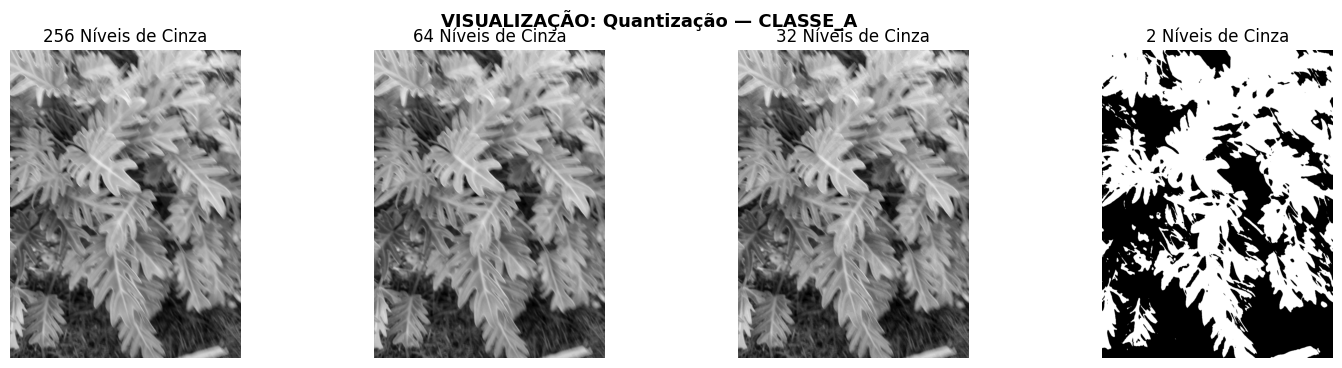

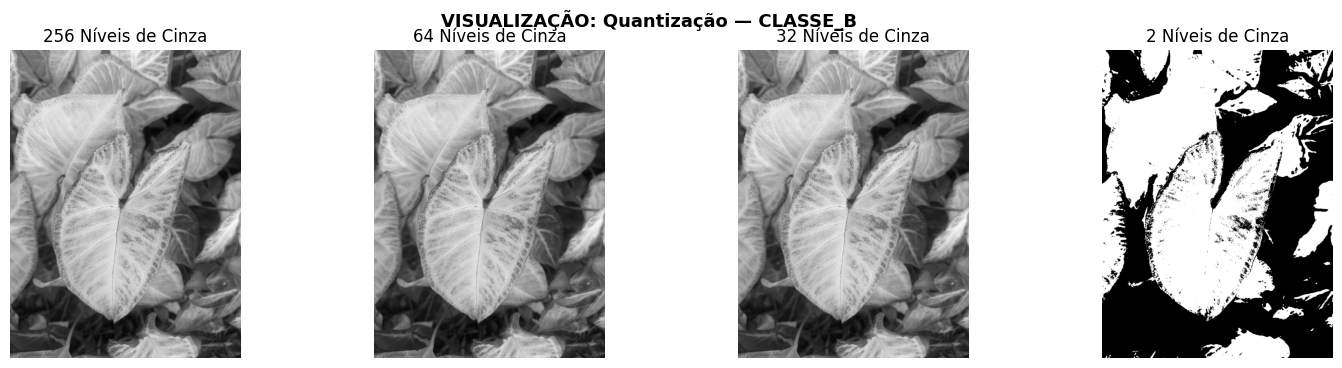


* **INTERPRETAÇÃO:**
  * *Degradação:* Em 64 e 32 níveis surge o efeito de *falso contorno* (*banding*), transformando gradientes suaves em degraus abruptos. Em 2 níveis obtém-se a imagem binarizada.
  * *Utilidade no Dataset:*
    * **256 níveis (8 bits):** É a versão ideal para classificação de folhas e flores, onde texturas sutis são essenciais.
    * **2 níveis (1 bit):** Essencial para operações morfológicas, contagem de objetos, remoção de fundo e segmentação rápida de silhuetas.


In [5]:
display(Markdown("""
---
###  PROBLEMA 4: Quantização de Níveis de Cinza e Profundidade de Bits
* **Objetivo:** Analisar os efeitos da redução de níveis de intensidade (256, 64, 32 e 2 níveis) sobre a degradação visual e a geração de contornos falsos.
"""))

def quantizar(img_gray, niveis):
    if niveis == 2:
        _, res = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
        return res
    fator = 256 // niveis
    return (img_gray // fator) * fator

def executar_quantizacao(img, nome_classe):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    niveis_lista = [256, 64, 32, 2]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for idx, n in enumerate(niveis_lista):
        quant = gray if n == 256 else quantizar(gray, n)
        cv2.imwrite(f"outputs/quantizacao/{nome_classe}_{n}niveis.png", quant)
        axes[idx].imshow(quant, cmap='gray')
        axes[idx].set_title(f"{n} Níveis de Cinza")
        axes[idx].axis('off')

    plt.suptitle(f"VISUALIZAÇÃO: Quantização — {nome_classe.upper()}", fontsize=13, fontweight='bold')
    plt.show()

executar_quantizacao(img_a, "classe_A")
executar_quantizacao(img_b, "classe_B")

display(Markdown("""
* **INTERPRETAÇÃO:**
  * *Degradação:* Em 64 e 32 níveis surge o efeito de *falso contorno* (*banding*), transformando gradientes suaves em degraus abruptos. Em 2 níveis obtém-se a imagem binarizada.
  * *Utilidade no Dataset:*
    * **256 níveis (8 bits):** É a versão ideal para classificação de folhas e flores, onde texturas sutis são essenciais.
    * **2 níveis (1 bit):** Essencial para operações morfológicas, contagem de objetos, remoção de fundo e segmentação rápida de silhuetas.
"""))

In [6]:
display(Markdown("""
---
###  PROBLEMA 5: Formatos de Arquivo e Compressão (JPEG vs PNG)
* **Objetivo:** Comparar o tamanho de arquivo ($KB$) e a preservação de fidelidade visual entre formatos com perdas (JPEG com compressão) e sem perdas (PNG).
"""))

def executar_formatos(img, nome_classe):
    caminho_jpg = f"outputs/formatos/{nome_classe}_comprimido.jpg"
    caminho_png = f"outputs/formatos/{nome_classe}_sem_perdas.png"

    cv2.imwrite(caminho_jpg, img, [cv2.IMWRITE_JPEG_QUALITY, 40])
    cv2.imwrite(caminho_png, img,)

    tam_jpg = os.path.getsize(caminho_jpg) / 1024
    tam_png = os.path.getsize(caminho_png) / 1024

    print(f"[{nome_classe.upper()}]")
    print(f" • JPEG Comprimido (Q=40): {tam_jpg:.2f} KB")
    print(f" • PNG Sem Perdas:         {tam_png:.2f} KB")
    print(f" • Razão PNG / JPEG:       {tam_png / tam_jpg:.2f}x maior no formato PNG\n")

executar_formatos(img_a, "classe_A")
executar_formatos(img_b, "classe_B")

display(Markdown("""
* **INTERPRETAÇÃO:**
  * *Tamanho e Compressão:* O PNG preserva todos os valores originais, resultando em arquivos significativamente mais pesados. O JPEG descarta componentes de alta frequência via DCT, reduzindo drasticamente o tamanho do arquivo.
  * *Impacto em PDI:* O JPEG é ideal para armazenamento em massa e transmissão web de datasets para Deep Learning. O PNG é mandatório em aplicações médicas, metrologia e visão industrial de alta precisão.
"""))


---
###  PROBLEMA 5: Formatos de Arquivo e Compressão (JPEG vs PNG)
* **Objetivo:** Comparar o tamanho de arquivo ($KB$) e a preservação de fidelidade visual entre formatos com perdas (JPEG com compressão) e sem perdas (PNG).


[CLASSE_A]
 • JPEG Comprimido (Q=40): 92.21 KB
 • PNG Sem Perdas:         2390.38 KB
 • Razão PNG / JPEG:       25.92x maior no formato PNG

[CLASSE_B]
 • JPEG Comprimido (Q=40): 101.47 KB
 • PNG Sem Perdas:         2343.94 KB
 • Razão PNG / JPEG:       23.10x maior no formato PNG




* **INTERPRETAÇÃO:**
  * *Tamanho e Compressão:* O PNG preserva todos os valores originais, resultando em arquivos significativamente mais pesados. O JPEG descarta componentes de alta frequência via DCT, reduzindo drasticamente o tamanho do arquivo.
  * *Impacto em PDI:* O JPEG é ideal para armazenamento em massa e transmissão web de datasets para Deep Learning. O PNG é mandatório em aplicações médicas, metrologia e visão industrial de alta precisão.


In [7]:
display(Markdown("""
---
##  Tabela Resumo dos Métodos Aplicados

| Método de PDI | Configurações Avaliadas | Vantagens | Desvantagens / Perdas | Recomendação de Aplicação |
| :--- | :--- | :--- | :--- | :--- |
| **Resolução Espacial** | Original, -50%, -20% | Redução drástica do custo computacional e memória VRAM. | Perda de detalhes finos e texturas em reduções severas (-20%). | Treinamento de CNNs (resoluções médias padronizadas). |
| **Espaço de Cor** | RGB, HSV, Escala de Cinza | HSV isola cor e brilho; Escala de Cinza reduz 3 canais para 1. | Escala de cinza perde distinção cromática; HSV exige conversão. | HSV para segmentação por cor; Cinza para detecção de bordas/formas. |
| **Quantização** | 256, 64, 32, 2 níveis | Redução da profundidade de bits e simplificação da imagem. | Efeito de falso contorno (*banding*) em 32/64 níveis. | 256 níveis para texturas ricas; 2 níveis para máscaras binárias. |
| **Formato de Arquivo**| JPEG (Lossy) vs PNG (Lossless)| JPEG economiza banda/disco; PNG garante fidelidade absoluta. | JPEG gera artefatos de bloco; PNG tem arquivos muito maiores. | JPEG para datasets massivos; PNG para metrologia e imagens médicas. |

---

##  Respostas às Perguntas Conclusivas da Atividade

1. **Qual é o impacto das decisões de aquisição na qualidade de um pipeline de Visão Computacional?**
   * *Resposta:* Uma aquisição deficiente (com ruído excessivo, desfoque ou iluminação inadequada) não pode ser corrigida de forma perfeita na etapa de software. O controle de iluminação e distância é a etapa mais crítica para garantir que os modelos aprendam características reais do objeto e não artefatos da câmera.

2. **Como a escolha do formato e da resolução afeta o equilíbrio entre custo computacional e precisão?**
   * *Resposta:* Utilizar resoluções excessivas (ex: 108 MP) satura a memória sem ganhos proporcionais de acurácia. A engenharia de PDI reside em encontrar a menor resolução e compressão (ex: JPEG qualidade 85, dimensões médias) que preserve as altas frequências essenciais para a tarefa específica.
"""))


---
##  Tabela Resumo dos Métodos Aplicados

| Método de PDI | Configurações Avaliadas | Vantagens | Desvantagens / Perdas | Recomendação de Aplicação |
| :--- | :--- | :--- | :--- | :--- |
| **Resolução Espacial** | Original, -50%, -20% | Redução drástica do custo computacional e memória VRAM. | Perda de detalhes finos e texturas em reduções severas (-20%). | Treinamento de CNNs (resoluções médias padronizadas). |
| **Espaço de Cor** | RGB, HSV, Escala de Cinza | HSV isola cor e brilho; Escala de Cinza reduz 3 canais para 1. | Escala de cinza perde distinção cromática; HSV exige conversão. | HSV para segmentação por cor; Cinza para detecção de bordas/formas. |
| **Quantização** | 256, 64, 32, 2 níveis | Redução da profundidade de bits e simplificação da imagem. | Efeito de falso contorno (*banding*) em 32/64 níveis. | 256 níveis para texturas ricas; 2 níveis para máscaras binárias. |
| **Formato de Arquivo**| JPEG (Lossy) vs PNG (Lossless)| JPEG economiza banda/disco; PNG garante fidelidade absoluta. | JPEG gera artefatos de bloco; PNG tem arquivos muito maiores. | JPEG para datasets massivos; PNG para metrologia e imagens médicas. |

---

##  Respostas às Perguntas Conclusivas da Atividade

1. **Qual é o impacto das decisões de aquisição na qualidade de um pipeline de Visão Computacional?**
   * *Resposta:* Uma aquisição deficiente (com ruído excessivo, desfoque ou iluminação inadequada) não pode ser corrigida de forma perfeita na etapa de software. O controle de iluminação e distância é a etapa mais crítica para garantir que os modelos aprendam características reais do objeto e não artefatos da câmera.

2. **Como a escolha do formato e da resolução afeta o equilíbrio entre custo computacional e precisão?**
   * *Resposta:* Utilizar resoluções excessivas (ex: 108 MP) satura a memória sem ganhos proporcionais de acurácia. A engenharia de PDI reside em encontrar a menor resolução e compressão (ex: JPEG qualidade 85, dimensões médias) que preserve as altas frequências essenciais para a tarefa específica.



---
###  PROBLEMA: Análise de Histogramas de Intensidade e Canais RGB (Todas as 10 Amostras)
* **Objetivo:** Analisar a distribuição estatística de brilho e as assinaturas de cores R, G e B de todas as 10 imagens do mini dataset.


1. HISTOGRAMAS EM ESCALA DE CINZA (10 IMAGENS)


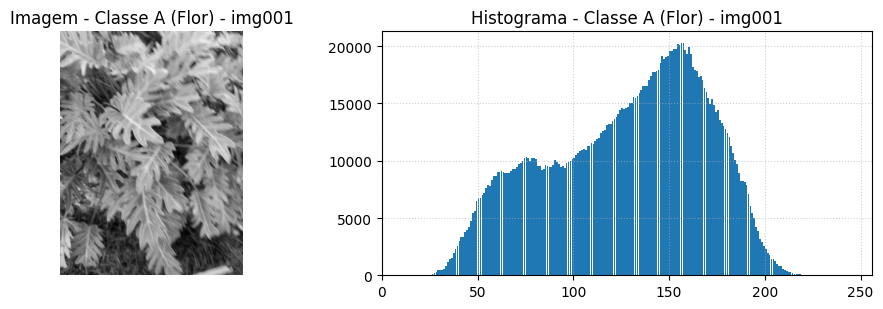

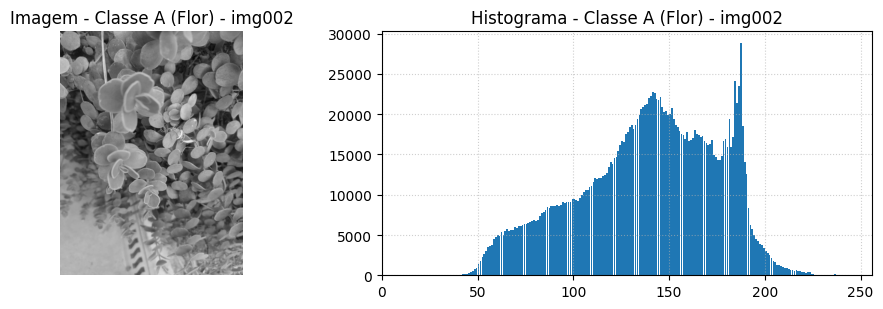

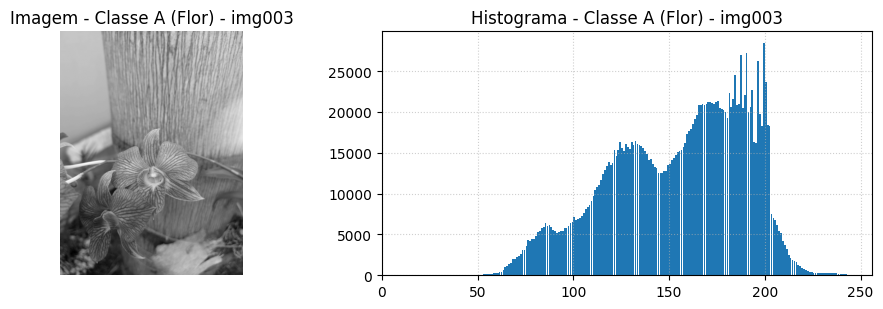

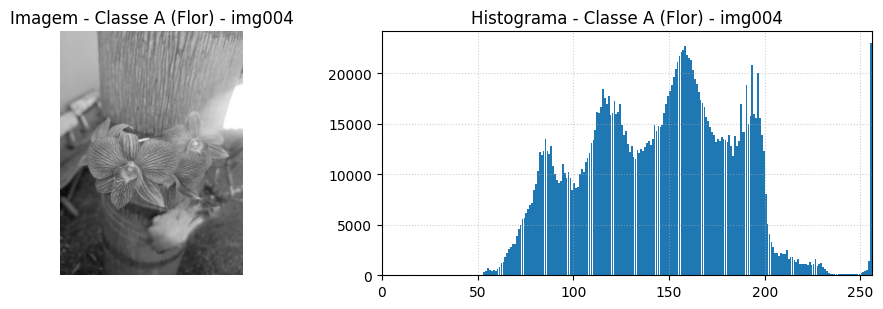

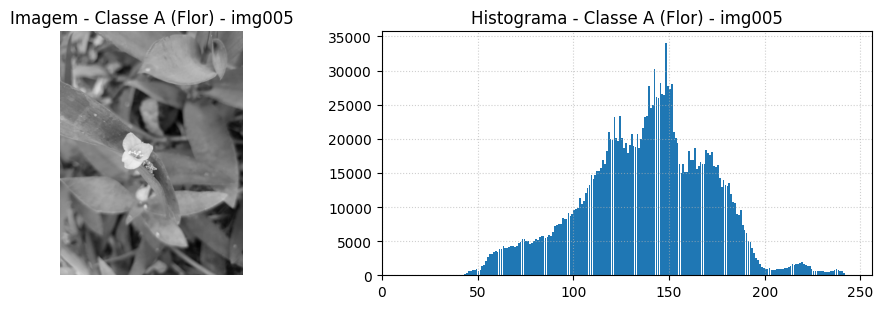

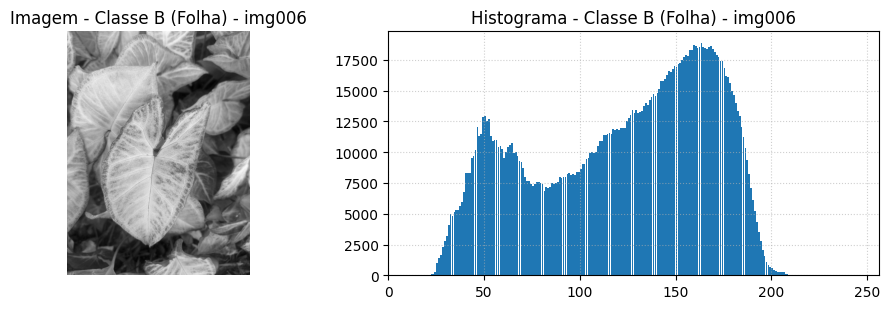

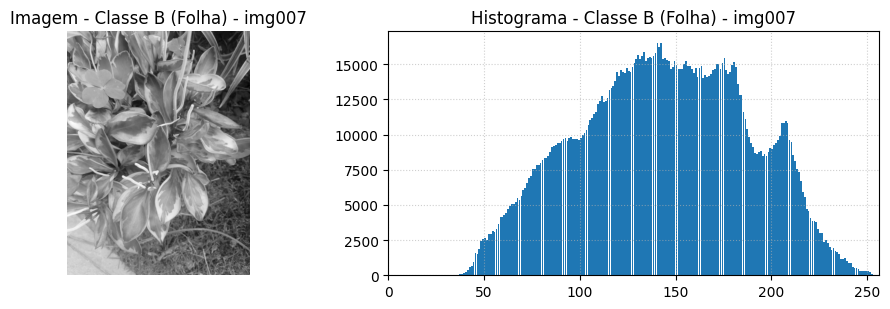

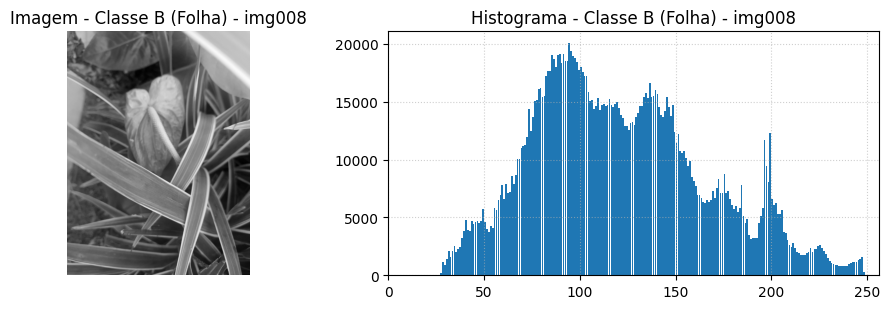

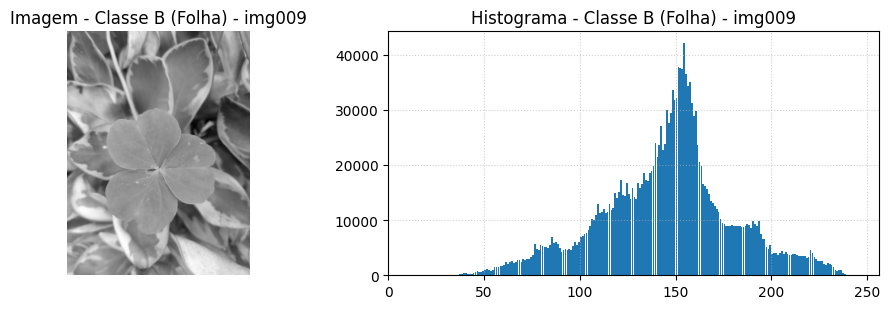

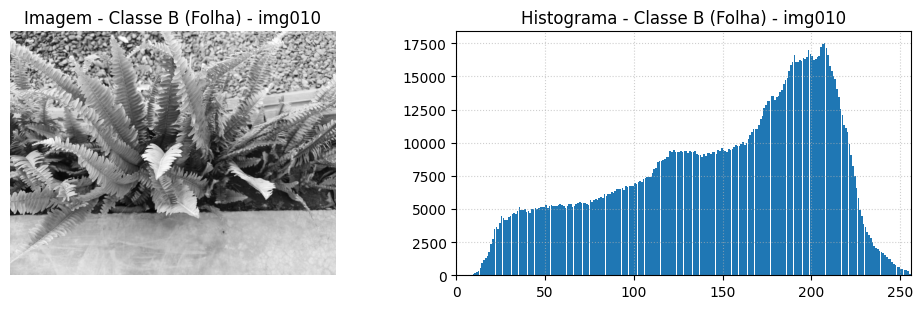


2. HISTOGRAMAS DOS CANAIS RGB (10 IMAGENS)


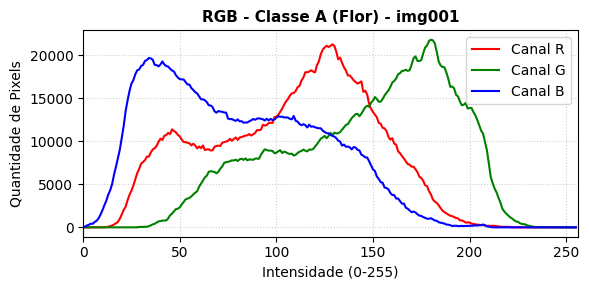

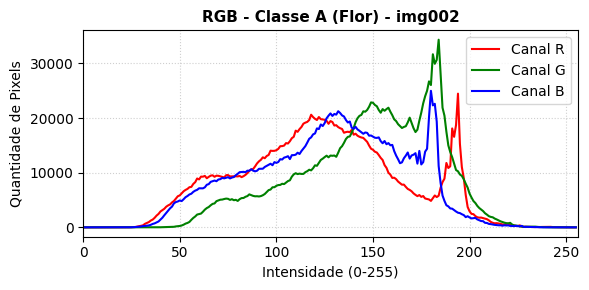

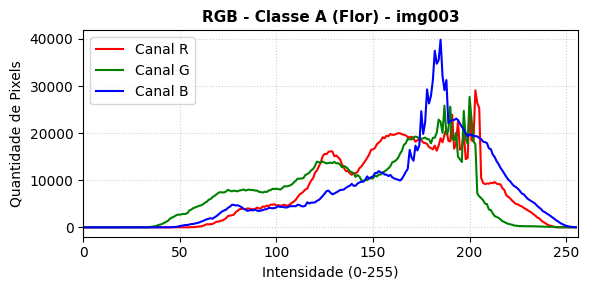

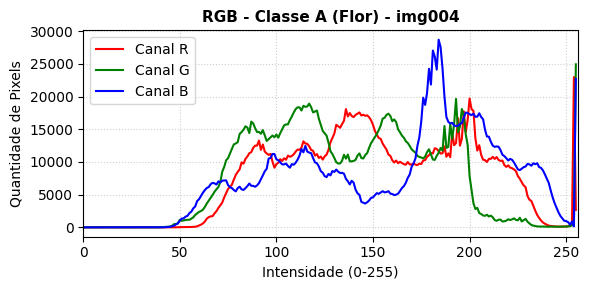

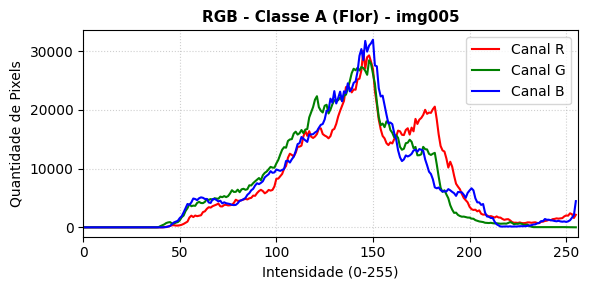

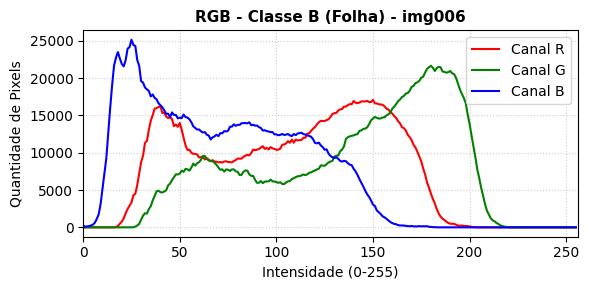

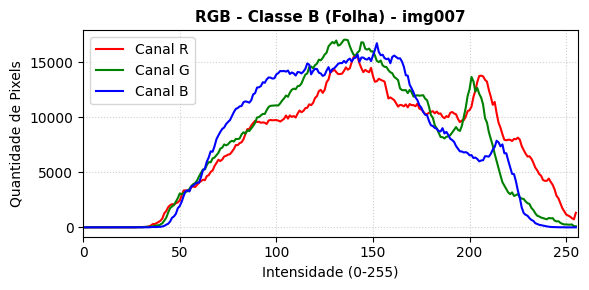

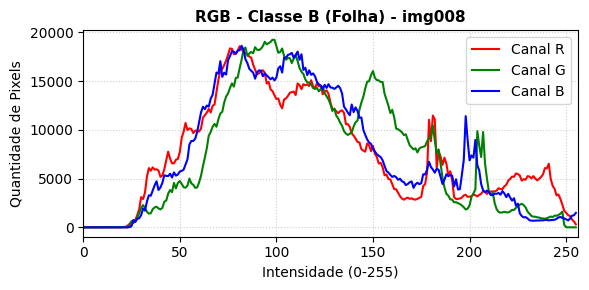

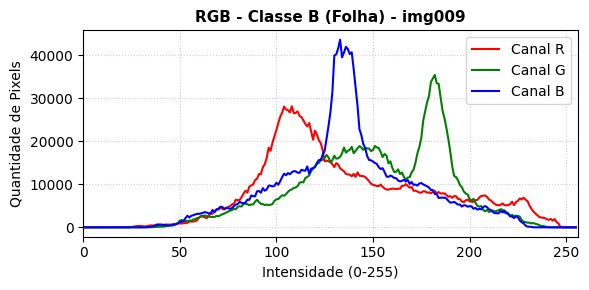

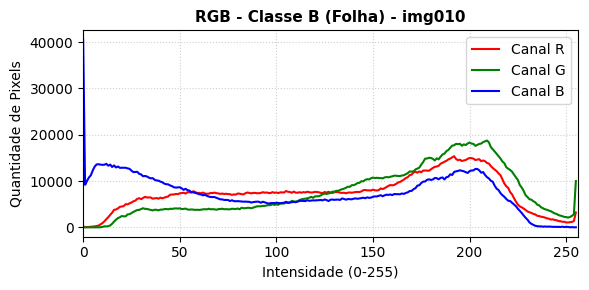


* **INTERPRETAÇÃO COMPARATIVA DAS 10 AMOSTRAS:**
  * *Contraste e Exposição:* As imagens sob luz natural direta apresentam histogramas mais amplos e espalhados em toda a faixa de 0 a 255. As imagens capturadas na sombra concentram seus valores nas faixas de luminância intermediárias, sem picos extremos de saturação.
  * *Distribuição Cromática:* Na **Classe A (Flores)**, nota-se variações significativas nos canais R e B dependendo da coloração da flor. Na **Classe B (Folhas)**, observa-se um padrão constante de dominância do canal verde (G) e menor presença do canal azul (B) em todas as amostras.


In [8]:
display(Markdown("""
---
###  PROBLEMA: Análise de Histogramas de Intensidade e Canais RGB (Todas as 10 Amostras)
* **Objetivo:** Analisar a distribuição estatística de brilho e as assinaturas de cores R, G e B de todas as 10 imagens do mini dataset.
"""))

# 1. Montar a lista com o caminho e rótulo de todas as 10 imagens
imagens_dataset = []
for i in range(1, 6):
    imagens_dataset.append((f"dataset/classe_A/img{i:03d}_original.jpg", f"Classe A (Flor) - img{i:03d}"))
for i in range(6, 11):
    imagens_dataset.append((f"dataset/classe_B/img{i:03d}_original.jpg", f"Classe B (Folha) - img{i:03d}"))

# 2. Plotar Histogramas em Escala de Cinza para todas as 10 imagens
print("=" * 60)
print("1. HISTOGRAMAS EM ESCALA DE CINZA (10 IMAGENS)")
print("=" * 60)

for caminho, rotulo in imagens_dataset:
    img = cv2.imread(caminho)
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
        axes[0].imshow(gray, cmap='gray')
        axes[0].set_title(f"Imagem - {rotulo}")
        axes[0].axis('off')

        # Correção: Chamar hist no subplot correto (axes[1])
        axes[1].hist(gray.ravel(), bins=256, range=[0, 256], color='#1f77b4', rwidth=0.9)
        axes[1].set_title(f"Histograma - {rotulo}")
        axes[1].set_xlim([0, 256])
        axes[1].grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()
        plt.show()

# 3. Plotar Histogramas dos Canais RGB para todas as 10 imagens
print("\n" + "=" * 60)
print("2. HISTOGRAMAS DOS CANAIS RGB (10 IMAGENS)")
print("=" * 60)

for caminho, rotulo in imagens_dataset:
    img = cv2.imread(caminho)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6, 3))
        for i, c in enumerate(["r", "g", "b"]):
            hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
            plt.plot(hist, color=c, label=f"Canal {c.upper()}")

        plt.title(f"RGB - {rotulo}", fontsize=11, fontweight='bold')
        plt.xlim([0, 256])
        plt.xlabel("Intensidade (0-255)")
        plt.ylabel("Quantidade de Pixels")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

# 4. Interpretação Técnica Geral
display(Markdown("""
* **INTERPRETAÇÃO COMPARATIVA DAS 10 AMOSTRAS:**
  * *Contraste e Exposição:* As imagens sob luz natural direta apresentam histogramas mais amplos e espalhados em toda a faixa de 0 a 255. As imagens capturadas na sombra concentram seus valores nas faixas de luminância intermediárias, sem picos extremos de saturação.
  * *Distribuição Cromática:* Na **Classe A (Flores)**, nota-se variações significativas nos canais R e B dependendo da coloração da flor. Na **Classe B (Folhas)**, observa-se um padrão constante de dominância do canal verde (G) e menor presença do canal azul (B) em todas as amostras.
"""))

In [9]:
import os

# Assuming the current working directory is /content/visao_computacional_mini_dataset

# 1. Converte o arquivo limpo (que termina na Tabela Resumo)
!jupyter nbconvert --to html /content/visao_computacional_mini_dataset/notebooks/relatorio_atividade_1_projeto.ipynb --output relatorio_final_limpo.html

# 2. Baixar o arquivo HTML limpo
from google.colab import files
files.download('/content/visao_computacional_mini_dataset/notebooks/relatorio_final_limpo.html')

[NbConvertApp] Converting notebook /content/visao_computacional_mini_dataset/notebooks/relatorio_atividade_1_projeto.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 27 image(s).
[NbConvertApp] Writing 7725313 bytes to /content/visao_computacional_mini_dataset/notebooks/relatorio_final_limpo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>